In [1]:
# ============================================
# Step 1: Import required libraries
# ============================================
import wrds
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set up matplotlib
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

print("=" * 60)
print("US Stock Daily Data Analysis Tool")
print("=" * 60)

# Connect to WRDS database
print("\nConnecting to WRDS database...")
conn = wrds.Connection()
print("✓ Database connected successfully!")

US Stock Daily Data Analysis Tool

Connecting to WRDS database...


Enter your WRDS username [lucka]: kangyuyao
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\lucka\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
✓ Database connected successfully!


In [2]:
# ============================================
# Step 2: Define core functions
# ============================================

def get_company_info_by_ticker(ticker, conn):
    """
    Get company information (including permno) by ticker symbol
    """
    ticker = ticker.upper()
    
    # Try exact match first
    query = f"""
        select distinct permno, ticker, comnam
        from crsp.msenames
        where ticker = '{ticker}'
        and namedt <= '2023-12-31'
        and nameendt >= '2023-01-01'
    """
    info = conn.raw_sql(query)
    
    if not info.empty:
        return info.iloc[0].to_dict()
    
    # If exact match fails, try fuzzy search
    query_fuzzy = f"""
        select distinct permno, ticker, comnam
        from crsp.msenames
        where ticker like '%{ticker}%'
        and namedt <= '2023-12-31'
        and nameendt >= '2023-01-01'
        limit 10
    """
    info_fuzzy = conn.raw_sql(query_fuzzy)
    
    if not info_fuzzy.empty:
        print(f"\n'{ticker}' not found. Similar companies:")
        for idx, row in info_fuzzy.iterrows():
            print(f"  {idx+1}. {row['ticker']} - {row['comnam']}")
        return None
    else:
        print(f"\nTicker not found: {ticker}")
        return None


def get_daily_data(permno, ticker, conn):
    """
    Get 2023 daily data and calculate metrics
    """
    query = f"""
        select date, prc, ret, shrout
        from crsp.dsf
        where permno = {permno}
        and date between '2023-01-01' and '2023-12-31'
    """
    data = conn.raw_sql(query, date_cols=['date'])
    
    if data.empty:
        print(f"Warning: No data for {ticker} in 2023")
        return None
    
    # Handle missing values
    data['ret'] = data['ret'].fillna(0)
    
    # Calculate cumulative return
    data['cum_ret'] = (1 + data['ret']).cumprod() - 1
    
    # Calculate 20-day rolling volatility (annualized)
    data['volatility'] = data['ret'].rolling(20).std() * (252 ** 0.5)
    
    # Add time features
    data['month'] = data['date'].dt.month
    data['weekday'] = data['date'].dt.day_name()
    
    # Calculate market cap (millions USD)
    data['mktcap'] = data['prc'].abs() * data['shrout'] * 1000 / 1e6
    
    data['ticker'] = ticker
    
    return data


def plot_comparison(data1, data2, name1, name2, ticker1, ticker2):
    """
    Generate comparison charts
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Chart 1: Cumulative Return Comparison
    axes[0, 0].plot(data1['date'], data1['cum_ret'] * 100, 
                   label=f'{ticker1} ({name1[:15]})', linewidth=1.5)
    axes[0, 0].plot(data2['date'], data2['cum_ret'] * 100, 
                   label=f'{ticker2} ({name2[:15]})', linewidth=1.5)
    axes[0, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[0, 0].set_title('Cumulative Return Comparison (2023)', fontsize=12)
    axes[0, 0].set_ylabel('Cumulative Return (%)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Chart 2: Volatility Comparison
    axes[0, 1].plot(data1['date'], data1['volatility'] * 100, 
                   label=f'{ticker1}', alpha=0.7)
    axes[0, 1].plot(data2['date'], data2['volatility'] * 100, 
                   label=f'{ticker2}', alpha=0.7)
    axes[0, 1].set_title('20-Day Rolling Volatility (Annualized)', fontsize=12)
    axes[0, 1].set_ylabel('Volatility (%)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Chart 3: Monthly Average Return Bar Chart
    monthly1 = data1.groupby('month')['ret'].mean() * 100
    monthly2 = data2.groupby('month')['ret'].mean() * 100
    x = np.arange(1, 13)
    width = 0.35
    axes[1, 0].bar(x - width/2, monthly1, width, label=f'{ticker1}', alpha=0.7)
    axes[1, 0].bar(x + width/2, monthly2, width, label=f'{ticker2}', alpha=0.7)
    axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    axes[1, 0].set_xlabel('Month')
    axes[1, 0].set_ylabel('Average Monthly Return (%)')
    axes[1, 0].set_title('Monthly Average Return Comparison', fontsize=12)
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Chart 4: Market Cap Change
    mktcap1_bn = data1['mktcap'] / 1000
    mktcap2_bn = data2['mktcap'] / 1000
    axes[1, 1].fill_between(data1['date'], mktcap1_bn, alpha=0.4, label=f'{ticker1}')
    axes[1, 1].fill_between(data2['date'], mktcap2_bn, alpha=0.4, label=f'{ticker2}')
    axes[1, 1].plot(data1['date'], mktcap1_bn, linewidth=1)
    axes[1, 1].plot(data2['date'], mktcap2_bn, linewidth=1)
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Market Cap (Billions USD)')
    axes[1, 1].set_title('Market Capitalization Comparison', fontsize=12)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save the figure
    filename = f'{ticker1}_vs_{ticker2}_comparison.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"✓ Chart saved: {filename}")
    
    plt.show()

In [3]:
# ============================================
# Step 3: User Input
# ============================================

print("\n" + "=" * 60)
print("Please enter two stock tickers to compare")
print("=" * 60)
print("Examples: AAPL, MSFT, GOOGL, AMZN, TSLA, META, NVDA, NFLX")
print("-" * 60)

# Get user input
ticker1 = input("Enter the first stock ticker: ").strip().upper()
ticker2 = input("Enter the second stock ticker: ").strip().upper()

print(f"\nYou selected: {ticker1} and {ticker2}")
print("\nRetrieving company information...")


Please enter two stock tickers to compare
Examples: AAPL, MSFT, GOOGL, AMZN, TSLA, META, NVDA, NFLX
------------------------------------------------------------


Enter the first stock ticker:  NVDA
Enter the second stock ticker:  META



You selected: NVDA and META

Retrieving company information...


In [4]:
# ============================================
# Step 4: Get Company Information
# ============================================

# Get first company information
print(f"\n--- Looking up {ticker1} ---")
info1 = get_company_info_by_ticker(ticker1, conn)

if info1 is None:
    print(f"Error: Cannot find ticker {ticker1}")
    print("Program will exit. Please rerun and enter a valid ticker.")
    conn.close()
    exit()

# Get second company information
print(f"\n--- Looking up {ticker2} ---")
info2 = get_company_info_by_ticker(ticker2, conn)

if info2 is None:
    print(f"Error: Cannot find ticker {ticker2}")
    print("Program will exit. Please rerun and enter a valid ticker.")
    conn.close()
    exit()

print("\n" + "=" * 60)
print("Company information retrieved successfully!")
print("=" * 60)
print(f"{ticker1}: {info1['comnam']} (permno={info1['permno']})")
print(f"{ticker2}: {info2['comnam']} (permno={info2['permno']})")


--- Looking up NVDA ---

--- Looking up META ---

Company information retrieved successfully!
NVDA: NVIDIA CORP (permno=86580)
META: META PLATFORMS INC (permno=13407)


In [5]:
# ============================================
# Step 5: Get Daily Data
# ============================================

print("\nRetrieving daily data...")

# Get first company data
data1 = get_daily_data(info1['permno'], ticker1, conn)
# Get second company data
data2 = get_daily_data(info2['permno'], ticker2, conn)

if data1 is None or data2 is None:
    print("Error: Unable to retrieve daily data")
    conn.close()
    exit()

print(f"\n✓ {ticker1} data retrieved: {len(data1)} trading days")
print(f"✓ {ticker2} data retrieved: {len(data2)} trading days")


Retrieving daily data...

✓ NVDA data retrieved: 250 trading days
✓ META data retrieved: 250 trading days


In [6]:
# ============================================
# Step 6: Calculate Statistics
# ============================================

# Calculate cumulative returns
ret1 = data1['cum_ret'].iloc[-1] * 100
ret2 = data2['cum_ret'].iloc[-1] * 100

# Calculate average volatility
vol1 = data1['volatility'].mean() * 100
vol2 = data2['volatility'].mean() * 100

# Calculate maximum drawdown
def max_drawdown(cum_ret):
    cum_wealth = 1 + cum_ret
    running_max = cum_wealth.expanding().max()
    drawdown = (cum_wealth - running_max) / running_max
    return drawdown.min() * 100

mdd1 = max_drawdown(data1['cum_ret'])
mdd2 = max_drawdown(data2['cum_ret'])

print("\n" + "=" * 60)
print("Summary Statistics")
print("=" * 60)
print(f"{'Metric':<30} {ticker1:<15} {ticker2:<15}")
print("-" * 60)
print(f"{'2023 Cumulative Return (%)':<30} {ret1:<15.2f} {ret2:<15.2f}")
print(f"{'Average Annualized Volatility (%)':<30} {vol1:<15.2f} {vol2:<15.2f}")
print(f"{'Maximum Drawdown (%)':<30} {mdd1:<15.2f} {mdd2:<15.2f}")
print(f"{'Number of Trading Days':<30} {len(data1):<15} {len(data2):<15}")

# Save summary statistics
summary_stats = pd.DataFrame({
    'Metric': ['Annual Return (%)', 'Average Volatility (%)', 'Max Drawdown (%)', 'Trading Days'],
    ticker1: [f"{ret1:.2f}", f"{vol1:.2f}", f"{mdd1:.2f}", len(data1)],
    ticker2: [f"{ret2:.2f}", f"{vol2:.2f}", f"{mdd2:.2f}", len(data2)]
})
summary_stats.to_csv(f'{ticker1}_vs_{ticker2}_summary.csv', index=False)
print(f"\n✓ Summary statistics saved: {ticker1}_vs_{ticker2}_summary.csv")


Summary Statistics
Metric                         NVDA            META           
------------------------------------------------------------
2023 Cumulative Return (%)     239.02          194.13         
Average Annualized Volatility (%) 45.23           36.82          
Maximum Drawdown (%)           -18.29          -12.97         
Number of Trading Days         250             250            

✓ Summary statistics saved: NVDA_vs_META_summary.csv


✓ Daily data saved: NVDA_2023_daily.csv
✓ Daily data saved: META_2023_daily.csv

Generating comparison charts...
✓ Chart saved: NVDA_vs_META_comparison.png


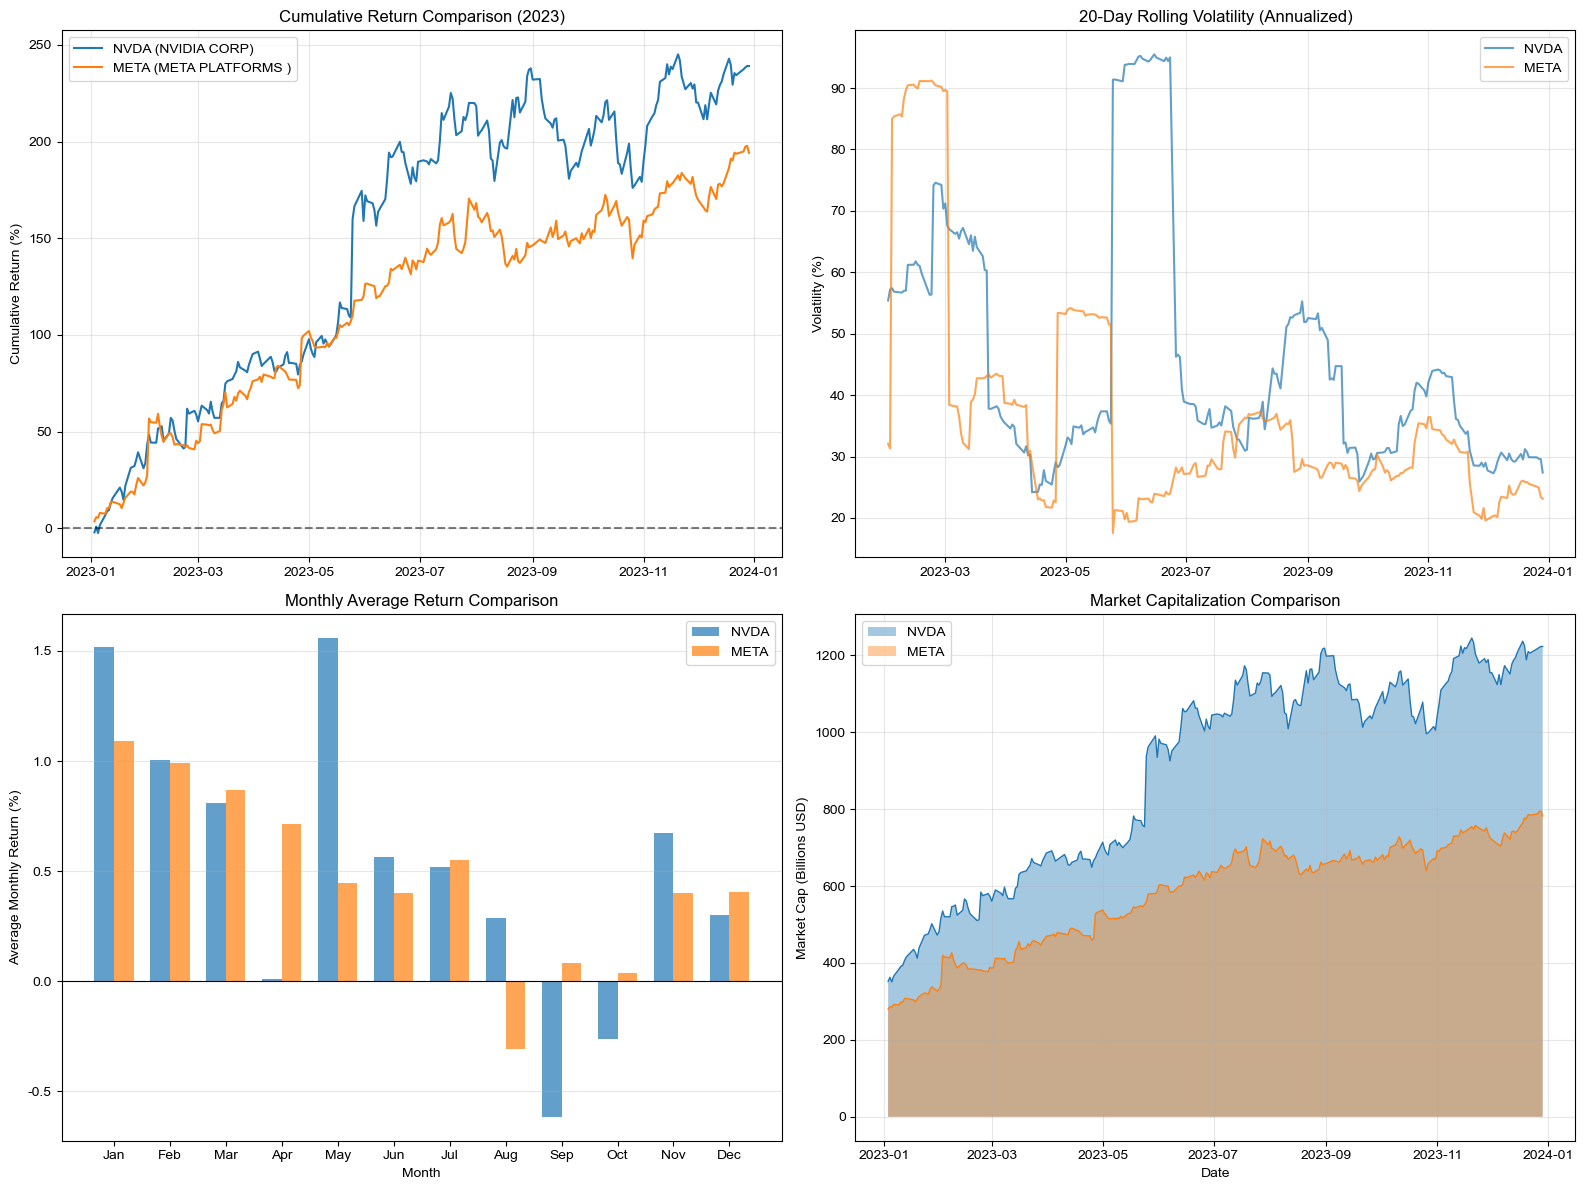


Analysis Complete!
Files generated:
  - NVDA_2023_daily.csv
  - META_2023_daily.csv
  - NVDA_vs_META_summary.csv
  - NVDA_vs_META_comparison.png


In [7]:
# ============================================
# Step 7: Save Raw Data
# ============================================

# Save daily data
data1.to_csv(f'{ticker1}_2023_daily.csv', index=False)
data2.to_csv(f'{ticker2}_2023_daily.csv', index=False)
print(f"✓ Daily data saved: {ticker1}_2023_daily.csv")
print(f"✓ Daily data saved: {ticker2}_2023_daily.csv")

# ============================================
# Step 8: Generate Comparison Charts
# ============================================

print("\nGenerating comparison charts...")
plot_comparison(data1, data2, info1['comnam'], info2['comnam'], ticker1, ticker2)

# ============================================
# Step 9: Close Connection
# ============================================

conn.close()
print("\n" + "=" * 60)
print("Analysis Complete!")
print("=" * 60)
print(f"Files generated:")
print(f"  - {ticker1}_2023_daily.csv")
print(f"  - {ticker2}_2023_daily.csv")
print(f"  - {ticker1}_vs_{ticker2}_summary.csv")
print(f"  - {ticker1}_vs_{ticker2}_comparison.png")